# 03 — Auditing Bias & Fairness

scikit-fair provides two auditors:

- **BiasAuditor** — analyses the dataset before modelling (group proportions, target rates)
- **FairnessAuditor** — evaluates a trained model's predictions (performance gaps, fairness metrics)

In [1]:
from skfair.datasets import load_ricci

X, y = load_ricci(preprocessed=True)

## Pre-model audit with BiasAuditor

BiasAuditor takes the features, target, and sensitive attribute. It reports
group proportions and positive-outcome rates per group.

In [2]:
from skfair.audit import BiasAuditor

bias = BiasAuditor(X, y, sens_attr="Race", priv_group=1, pos_label=1)
bias.group_proportions()

,count,proportion
Race,,
1,68,0.576271
0,50,0.423729


In [3]:
bias.target_rate_by_group()

,count,positive_rate
Race,,
0,50,0.300000
1,68,0.602941


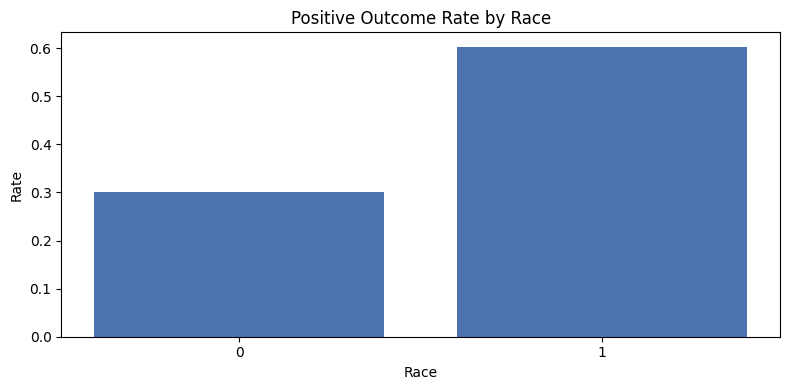

In [4]:
bias.plot_target_rates();

## Train a baseline model

We train a simple logistic regression to get predictions for the fairness audit.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
clf = LogisticRegression(solver="liblinear", max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

## Post-model audit with FairnessAuditor

FairnessAuditor takes the true labels, predicted labels, and the sensitive
attribute values for the test set. It computes per-group performance and
standard fairness metrics.

In [6]:
from skfair.audit import FairnessAuditor

fair = FairnessAuditor(y_test, y_pred, X_test["Race"], priv_group=1, pos_label=1)
fair.performance_by_group()

,unprivileged,privileged
Accuracy,0.666667,0.714286
TPR,0.400000,0.916667
FPR,0.200000,0.555556
TNR,0.800000,0.444444
FNR,0.600000,0.083333


In [7]:
fair.fairness_metrics()

,value
Disparate Impact,0.350000
Statistical Parity Diff,-0.495238
Equal Opportunity Diff,-0.516667
Equal Opportunity Ratio,0.436364
Average Odds Diff,-0.436111
TNR Difference,0.355556
FNR Difference,0.516667
Predictive Equality,0.360000
Accuracy Parity,0.933333


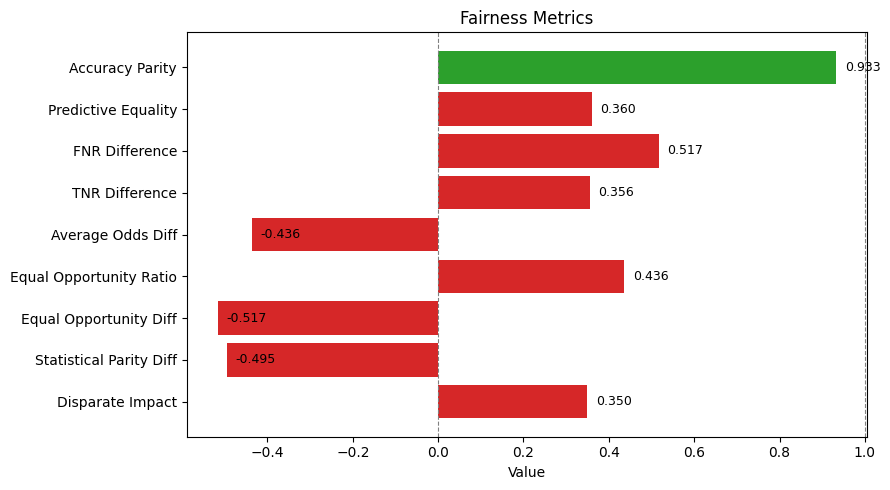

In [8]:
fair.plot_fairness_metrics();

Both auditors integrate with the Experiment class (notebook 05), which can
run bias and fairness audits automatically across multiple datasets and methods.